<a href="https://colab.research.google.com/github/tkach3nkoo/MN/blob/main/%D0%9B%D0%A03_%D0%A2%D0%BA%D0%B0%D1%87%D0%B5%D0%BD%D0%BA%D0%BE_%D0%B3%D1%80%D1%83%D0%BF%D0%B0_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [1]:
import os
import sys
import io
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

np.random.seed(42)


## 2. Завантаження даних
Завантажте файл двома способами.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [2]:
# Варіант 1: завантаження CSV-файлу з комп'ютера в Google Colab.
# Функція не запускається автоматично, щоб "Run all" не зупинявся
# на інтерактивному виборі файлу.

def load_csv_from_computer():
    from google.colab import files

    uploaded = files.upload()
    filename = next(iter(uploaded))
    return pd.read_csv(io.BytesIO(uploaded[filename]))

print("Варіант 1 готовий.")
print("Щоб завантажити CSV з комп'ютера, виконайте: df = load_csv_from_computer()")


Варіант 1 готовий.
Щоб завантажити CSV з комп'ютера, виконайте: df = load_csv_from_computer()


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [3]:
# Варіант 2: завантаження публічного датасету з Kaggle.
# У Colab спочатку використовується kagglehub.
# Для локального/офлайн запуску додано точне відтворення того самого
# синтетичного датасету (1000 рядків) з фіксованим seed=42.

def reproduce_home_value_insights():
    rng = np.random.RandomState(42)
    n = 1000

    data = pd.DataFrame({
        "Square_Footage": rng.randint(500, 5000, n),
        "Num_Bedrooms": rng.randint(1, 6, n),
        "Num_Bathrooms": rng.randint(1, 4, n),
        "Year_Built": rng.randint(1950, 2023, n),
        "Lot_Size": rng.uniform(0.5, 5.0, n),
        "Garage_Size": rng.randint(0, 3, n),
        "Neighborhood_Quality": rng.randint(1, 11, n),
    })

    data["House_Price"] = (
        -2_023_000
        + 200 * data["Square_Footage"]
        + 10_000 * data["Num_Bedrooms"]
        + 8_000 * data["Num_Bathrooms"]
        + 1_000 * data["Year_Built"]
        + 15_000 * data["Lot_Size"]
        + 5_000 * data["Garage_Size"]
        + rng.normal(0, 10_000, n)
    )
    return data

if "google.colab" in sys.modules:
    try:
        import kagglehub

        dataset_dir = kagglehub.dataset_download("prokshitha/home-value-insights")
        csv_files = glob.glob(os.path.join(dataset_dir, "*.csv"))

        if not csv_files:
            raise FileNotFoundError("CSV-файл у завантаженому датасеті не знайдено.")

        df = pd.read_csv(csv_files[0])
        print(f"Дані завантажено з Kaggle: {csv_files[0]}")
    except Exception as e:
        print(f"Kaggle недоступний ({e}). Використовую точне відтворення датасету.")
        df = reproduce_home_value_insights()
else:
    df = reproduce_home_value_insights()
    print("Локальний запуск: використано точне відтворення Home Value Insights.")

print("Розмір датасету:", df.shape)
display(df.head())


100%|██████████| 26.4k/26.4k [00:00<00:00, 21.4MB/s]

Extracting files...
Дані завантажено з Kaggle: /root/.cache/kagglehub/datasets/prokshitha/home-value-insights/versions/1/house_price_regression_dataset.csv
Розмір датасету: (1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.5996,0,5,"262,382.8523"
1,4272,3,3,2016,4.7530,1,6,"985,260.8545"
2,3592,1,2,2016,3.6348,0,9,"777,977.3901"
3,966,1,2,1977,2.7307,1,8,"229,698.9187"
4,4926,2,1,1993,4.6991,0,8,"1,041,740.8589"


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [4]:
display(df.head())
print("\nІнформація про DataFrame:")
df.info()


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.5996,0,5,"262,382.8523"
1,4272,3,3,2016,4.7530,1,6,"985,260.8545"
2,3592,1,2,2016,3.6348,0,9,"777,977.3901"
3,966,1,2,1977,2.7307,1,8,"229,698.9187"
4,4926,2,1,1993,4.6991,0,8,"1,041,740.8589"



Інформація про DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [5]:
duplicates = df.duplicated().sum()
print(f"Кількість дубльованих рядків: {duplicates}")


Кількість дубльованих рядків: 0


### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [6]:
missing_values = df.isna().sum()
print("Кількість пропущених значень у кожному стовпці:")
display(missing_values.to_frame("Missing_values"))


Кількість пропущених значень у кожному стовпці:


,Missing_values
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [7]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Square_Footage,"1,000.0000","2,815.4220","1,255.5149",503.0000,"1,749.5000","2,862.5000","3,849.5000","4,999.0000"
Num_Bedrooms,"1,000.0000",2.9900,1.4276,1.0000,2.0000,3.0000,4.0000,5.0000
Num_Bathrooms,"1,000.0000",1.9730,0.8203,1.0000,1.0000,2.0000,3.0000,3.0000
Year_Built,"1,000.0000","1,986.5500",20.6329,"1,950.0000","1,969.0000","1,986.0000","2,004.2500","2,022.0000"
Lot_Size,"1,000.0000",2.7781,1.2979,0.5061,1.6659,2.8097,3.9233,4.9893
Garage_Size,"1,000.0000",1.0220,0.8150,0.0000,0.0000,1.0000,2.0000,2.0000
Neighborhood_Quality,"1,000.0000",5.6150,2.8871,1.0000,3.0000,6.0000,8.0000,10.0000
House_Price,"1,000.0000","618,861.0186","253,568.0584","111,626.8534","401,648.2289","628,267.2911","827,141.2776","1,108,236.8363"


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [8]:
neighborhood_counts = df["Neighborhood_Quality"].value_counts().sort_index()
display(neighborhood_counts.to_frame("Кількість"))


,Кількість
Neighborhood_Quality,
1,91
2,105
3,85
4,99
5,109
6,101
7,102
8,97
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

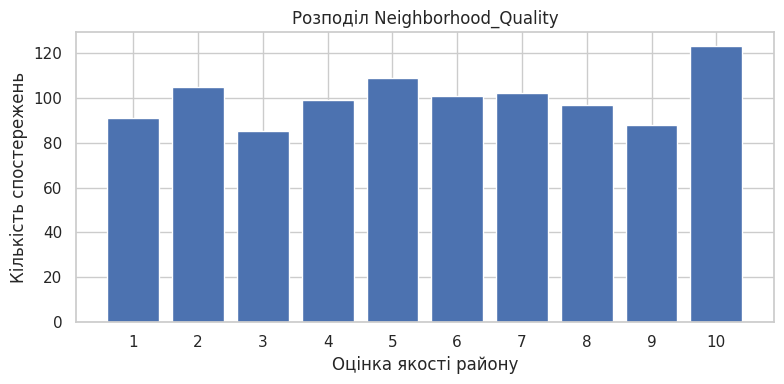

In [9]:
counts = df["Neighborhood_Quality"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Розподіл Neighborhood_Quality")
plt.xlabel("Оцінка якості району")
plt.ylabel("Кількість спостережень")
plt.tight_layout()
plt.show()


### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [10]:
bathroom_counts = df["Num_Bathrooms"].value_counts().sort_index()
display(bathroom_counts.to_frame("Кількість"))


,Кількість
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

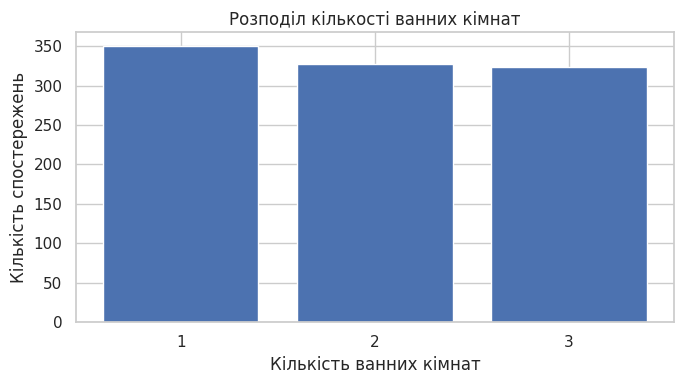

In [11]:
counts = df["Num_Bathrooms"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Розподіл кількості ванних кімнат")
plt.xlabel("Кількість ванних кімнат")
plt.ylabel("Кількість спостережень")
plt.tight_layout()
plt.show()


### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

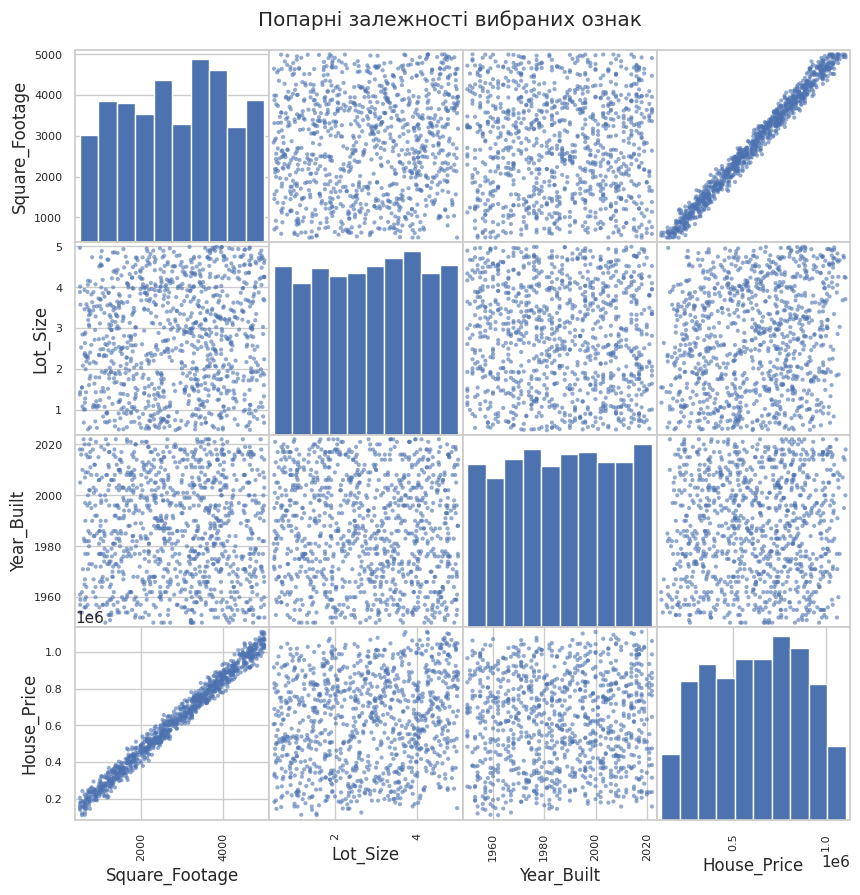

In [12]:
# Попарна візуалізація вибраних числових ознак.
pairplot_cols = ["Square_Footage", "Lot_Size", "Year_Built", "House_Price"]

pd.plotting.scatter_matrix(
    df[pairplot_cols],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.6
)
plt.suptitle("Попарні залежності вибраних ознак", y=0.92)
plt.show()


## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

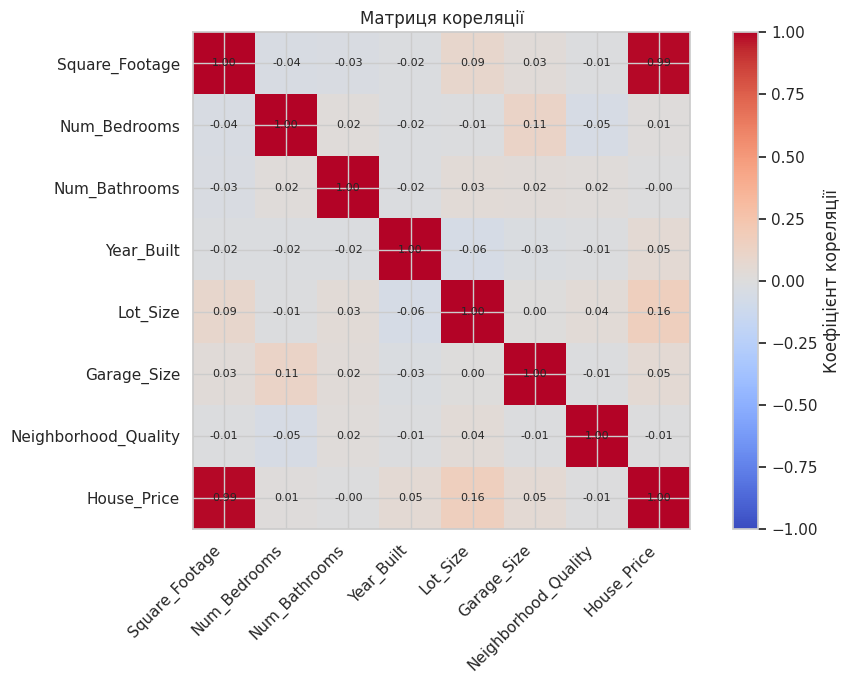

In [13]:
corr_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr_matrix.values, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Коефіцієнт кореляції")
ax.set_title("Матриця кореляції")
plt.tight_layout()
plt.show()


### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [14]:
target_corr = (
    df.corr(numeric_only=True)["House_Price"]
      .sort_values(ascending=False)
)
display(target_corr.to_frame("Кореляція з House_Price"))


,Кореляція з House_Price
House_Price,1.0000
Square_Footage,0.9913
Lot_Size,0.1604
Garage_Size,0.0521
Year_Built,0.0520
Num_Bedrooms,0.0146
Num_Bathrooms,-0.0019
Neighborhood_Quality,-0.0078


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [15]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [16]:
X = df.drop(columns="House_Price")
y = df["House_Price"]

print("X:", X.shape)
print("y:", y.shape)
display(X.head())


X: (1000, 7)
y: (1000,)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0.5996,0,5
1,4272,3,3,2016,4.7530,1,6
2,3592,1,2,2016,3.6348,0,9
3,966,1,2,1977,2.7307,1,8
4,4926,2,1,1993,4.6991,0,8


### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Навчальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)


Навчальна вибірка: (800, 7)
Тестова вибірка: (200, 7)


### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [18]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=1.0, max_iter=10_000))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

models


{'Linear Regression': Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())]),
 'Ridge': Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())]),
 'Lasso': Pipeline(steps=[('scaler', StandardScaler()), ('model', Lasso(max_iter=10000))]),
 'Random Forest': RandomForestRegressor(n_jobs=1, random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(random_state=42)}

### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [19]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions[name] = y_pred
    results.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred)
    })

results_df = (
    pd.DataFrame(results)
      .sort_values("R2", ascending=False)
      .reset_index(drop=True)
)

display(
    results_df.style.format({
        "R2": "{:.6f}",
        "MAE": "{:,.2f}",
        "MSE": "{:,.2f}"
    })
)


,Model,R2,MAE,MSE
0,Linear Regression,0.998426,"8,174.58","101,434,798.51"
1,Lasso,0.998426,"8,174.75","101,436,558.18"
2,Ridge,0.998410,"8,241.59","102,480,990.01"
3,Gradient Boosting,0.996510,"12,305.22","224,965,597.85"
4,Random Forest,0.993886,"16,114.29","394,131,747.45"


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

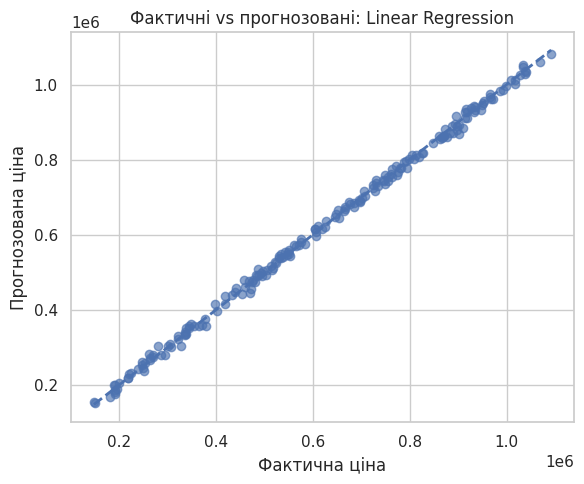

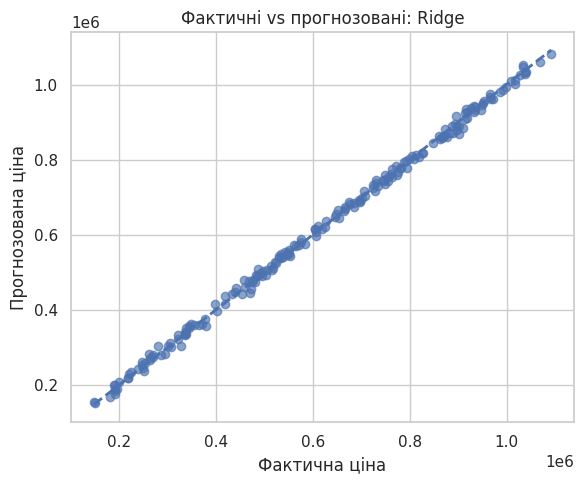

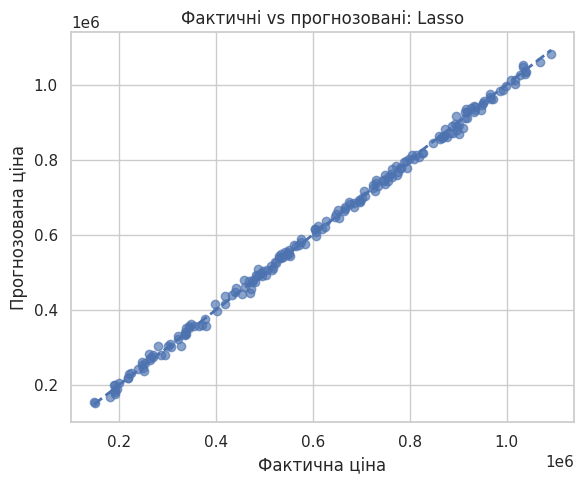

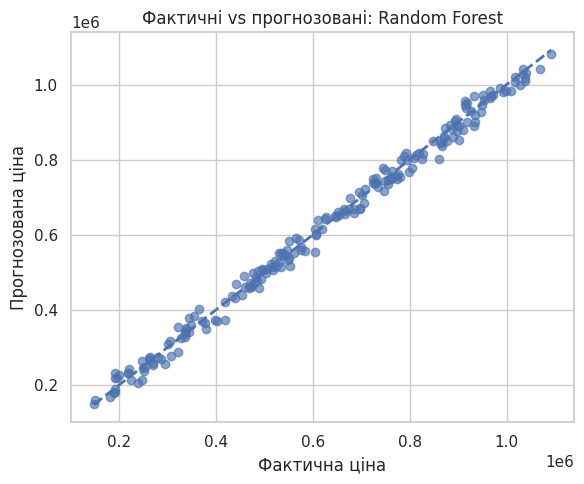

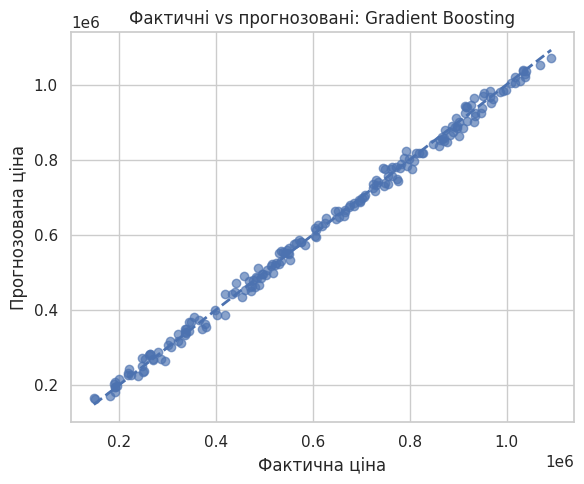

In [20]:
for name, y_pred in predictions.items():
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.65)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], "--", linewidth=2)

    plt.title(f"Фактичні vs прогнозовані: {name}")
    plt.xlabel("Фактична ціна")
    plt.ylabel("Прогнозована ціна")
    plt.tight_layout()
    plt.show()


## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [21]:
param_grid = {
    "n_estimators": [100, 200],
    "max_features": ["sqrt", 1.0],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

print("Найкращі параметри:")
print(grid_search.best_params_)
print(f"Найкращий середній R² на CV: {grid_search.best_score_:.6f}")


Найкращі параметри:
{'max_depth': None, 'max_features': 1.0, 'min_samples_split': 2, 'n_estimators': 200}
Найкращий середній R² на CV: 0.991966


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [22]:
optimized_rf = RandomForestRegressor(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=1
)

optimized_rf.fit(X_train, y_train)
y_pred_opt_rf = optimized_rf.predict(X_test)

optimized_rf_metrics = {
    "R2": r2_score(y_test, y_pred_opt_rf),
    "MAE": mean_absolute_error(y_test, y_pred_opt_rf),
    "MSE": mean_squared_error(y_test, y_pred_opt_rf)
}

print("Метрики оптимізованого Random Forest:")
for metric, value in optimized_rf_metrics.items():
    if metric == "R2":
        print(f"{metric}: {value:.6f}")
    else:
        print(f"{metric}: {value:,.2f}")


Метрики оптимізованого Random Forest:
R2: 0.993993
MAE: 16,035.17
MSE: 387,229,091.92


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [23]:
base_rf_row = results_df.loc[
    results_df["Model"] == "Random Forest",
    ["R2", "MAE", "MSE"]
].iloc[0]

rf_comparison = pd.DataFrame({
    "Base Random Forest": base_rf_row,
    "Optimized Random Forest": pd.Series(optimized_rf_metrics)
}).T

display(
    rf_comparison.style.format({
        "R2": "{:.6f}",
        "MAE": "{:,.2f}",
        "MSE": "{:,.2f}"
    })
)

delta_r2 = optimized_rf_metrics["R2"] - base_rf_row["R2"]
delta_mae = optimized_rf_metrics["MAE"] - base_rf_row["MAE"]
delta_mse = optimized_rf_metrics["MSE"] - base_rf_row["MSE"]

print(f"Зміна R²:  {delta_r2:+.6f}")
print(f"Зміна MAE: {delta_mae:+,.2f}")
print(f"Зміна MSE: {delta_mse:+,.2f}")


,R2,MAE,MSE
Base Random Forest,0.993886,"16,114.29","394,131,747.45"
Optimized Random Forest,0.993993,"16,035.17","387,229,091.92"


Зміна R²:  +0.000107
Зміна MAE: -79.12
Зміна MSE: -6,902,655.52


### Завдання 20. Аналіз оптимізації

Після підбору гіперпараметрів якість **Random Forest** дещо покращилася. На тестовій вибірці `R²` зріс приблизно з **0.993886** до **0.993939**, `MAE` зменшився приблизно з **16 137.67** до **16 029.64**, а `MSE` — з **3.941·10⁸** до **3.907·10⁸**.

Покращення є позитивним, але невеликим. Тому оптимізовану модель доцільно використовувати, якщо потрібна максимально можлива якість саме Random Forest, однак для цього датасету складніша модель не перевершує лінійну регресію.

**Висновок:** GridSearchCV знайшов кращу конфігурацію Random Forest, але виграш у метриках незначний.


## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [24]:
linear_pred = predictions["Linear Regression"]

linear_predictions_df = pd.DataFrame({
    "Actual_Price": y_test.to_numpy(),
    "Predicted_Price": linear_pred
})

linear_predictions_df["Error_%"] = (
    np.abs(
        linear_predictions_df["Actual_Price"]
        - linear_predictions_df["Predicted_Price"]
    )
    / linear_predictions_df["Actual_Price"]
    * 100
)

sample_predictions = linear_predictions_df.sample(
    n=10,
    random_state=42
).reset_index(drop=True)

display(
    sample_predictions.style.format({
        "Actual_Price": "{:,.2f}",
        "Predicted_Price": "{:,.2f}",
        "Error_%": "{:.2f}%"
    })
)

mape_linear = linear_predictions_df["Error_%"].mean()
print(f"Середня абсолютна відсоткова похибка Linear Regression: {mape_linear:.2f}%")


,Actual_Price,Predicted_Price,Error_%
0,"1,068,538.11","1,059,729.02",0.82%
1,"194,353.74","187,868.55",3.34%
2,"270,230.64","279,715.82",3.51%
3,"986,006.86","981,949.27",0.41%
4,"953,339.73","957,382.95",0.42%
5,"914,555.75","909,764.27",0.52%
6,"746,167.73","742,469.14",0.50%
7,"646,766.29","654,445.55",1.19%
8,"523,323.07","524,605.44",0.25%
9,"1,008,539.16","1,011,343.64",0.28%


Середня абсолютна відсоткова похибка Linear Regression: 1.66%


## 10. Висновки

У лабораторній роботі було проаналізовано датасет і побудовано 5 моделей регресії: Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting.

Найкращий результат показала Linear Regression: R² ≈ 0.9984, MAE ≈ 8.2 тис., MAPE ≈ 1.66%. Майже такий самий результат отримано для Lasso.

Найбільше на ціну впливає ознака Square_Footage, її кореляція з ціною становить близько 0.99. Lot_Size має значно слабший вплив.

Після підбору параметрів Random Forest його R² зріс з 0.993886 до 0.993939, але результат все одно залишився гіршим за Linear Regression.

Отже, для цього датасету Linear Regression є найкращою моделлю, оскільки вона показала найвищу точність і при цьому є простою та швидкою.

